In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib
import json
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, matthews_corrcoef,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.float_format", lambda x: "%.6f" % x)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

with open("../../data/network_anomaly/meta.json") as f:
    meta = json.load(f)

feature_cols = meta["feature_cols"]

train_df = pd.read_csv("../../data/network_anomaly/train_engineered.csv")
test_df = pd.read_csv("../../data/network_anomaly/test_engineered.csv")

train_labels = pd.read_csv("../../data/network_anomaly/train_cleaned.csv")[["is_attack"]]
test_labels = pd.read_csv("../../data/network_anomaly/test_cleaned.csv")[["is_attack"]]

feature_cols = [c for c in feature_cols if c in train_df.columns]

X_train = train_df[feature_cols].fillna(0)
y_train = train_labels["is_attack"]
X_test = test_df[feature_cols].fillna(0)
y_test = test_labels["is_attack"]

scaler = RobustScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

os.makedirs("../../models/network_anomaly", exist_ok=True)
joblib.dump(scaler, "../../models/network_anomaly/scaler.pkl")
joblib.dump(feature_cols, "../../models/network_anomaly/feature_names.pkl")

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train attack rate: {y_train.mean()*100:.2f}%")
print(f"Test attack rate : {y_test.mean()*100:.2f}%")

Train: (125973, 58) | Test: (22544, 58)
Train attack rate: 46.54%
Test attack rate : 56.92%


In [3]:
#  Business Cost and Evaluation
COST_FALSE_NEGATIVE = 100000
COST_FALSE_POSITIVE = 500
REWARD_TRUE_POSITIVE = 50000

print("NETWORK SECURITY BUSINESS COST MATRIX")
print()
print(f"False Negative (missed attack)   : -${COST_FALSE_NEGATIVE:,}  (breach cost)")
print(f"False Positive (false alarm)     : -${COST_FALSE_POSITIVE:,}    (investigation cost)")
print(f"True Positive (caught attack)    : +${REWARD_TRUE_POSITIVE:,}  (prevented breach)")

def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = int(tp) * REWARD_TRUE_POSITIVE + int(fn) * -COST_FALSE_NEGATIVE + int(fp) * -COST_FALSE_POSITIVE
    return int(cost), int(tn), int(fp), int(fn), int(tp)

def optimal_threshold(y_true, y_prob):
    best_t, best_cost = 0.5, -np.inf
    for t in np.arange(0.01, 0.99, 0.01):
        y_pred = (y_prob >= t).astype(int)
        if y_pred.sum() == 0:
            continue
        cost, *_ = business_cost(y_true, y_pred)
        if cost > best_cost:
            best_cost = cost
            best_t = t
    return best_t

def evaluate(name, y_true, y_prob):
    threshold = optimal_threshold(y_true, y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    cost, tn, fp, fn, tp = business_cost(y_true, y_pred)
    result = {
        "name": name,
        "threshold": round(float(threshold), 4),
        "auc_roc": round(float(roc_auc_score(y_true, y_prob)), 6),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 6),
        "f1": round(float(f1_score(y_true, y_pred)), 6),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 6),
        "recall": round(float(recall_score(y_true, y_pred)), 6),
        "mcc": round(float(matthews_corrcoef(y_true, y_pred)), 6),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "business_value": cost, "y_prob": y_prob
    }
    print(f"{name} | AUC={result['auc_roc']} | F1={result['f1']} | Recall={result['recall']} | Value=${cost:,}")
    return result

print()
print("Evaluation functions ready.")

NETWORK SECURITY BUSINESS COST MATRIX

False Negative (missed attack)   : -$100,000  (breach cost)
False Positive (false alarm)     : -$500    (investigation cost)
True Positive (caught attack)    : +$50,000  (prevented breach)

Evaluation functions ready.


In [4]:
# Train All Models
print("TRAINING ALL MODELS")
print()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=42, n_jobs=-1, tree_method="hist"
)
cv_xgb = cross_val_score(xgb_model, X_train_s, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"XGBoost CV AUC    : {cv_xgb.mean():.4f} (+/- {cv_xgb.std():.4f})")
xgb_model.fit(X_train_s, y_train)
joblib.dump(xgb_model, "../../models/network_anomaly/xgb_model.pkl")

lgbm_model = LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
)
cv_lgbm = cross_val_score(lgbm_model, X_train_s, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"LightGBM CV AUC   : {cv_lgbm.mean():.4f} (+/- {cv_lgbm.std():.4f})")
lgbm_model.fit(X_train_s, y_train)
joblib.dump(lgbm_model, "../../models/network_anomaly/lgbm_model.pkl")

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight="balanced",
    random_state=42, n_jobs=-1
)
cv_rf = cross_val_score(rf_model, X_train_s, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"RandomForest CV AUC: {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")
rf_model.fit(X_train_s, y_train)
joblib.dump(rf_model, "../../models/network_anomaly/rf_model.pkl")

print()
print("Evaluating on test set:")
xgb_prob = xgb_model.predict_proba(X_test_s)[:, 1]
lgbm_prob = lgbm_model.predict_proba(X_test_s)[:, 1]
rf_prob = rf_model.predict_proba(X_test_s)[:, 1]

xgb_results = evaluate("XGBoost", y_test, xgb_prob)
lgbm_results = evaluate("LightGBM", y_test, lgbm_prob)
rf_results = evaluate("RandomForest", y_test, rf_prob)
results_list = [xgb_results, lgbm_results, rf_results]

TRAINING ALL MODELS

XGBoost CV AUC    : 1.0000 (+/- 0.0000)
LightGBM CV AUC   : 1.0000 (+/- 0.0000)
RandomForest CV AUC: 1.0000 (+/- 0.0000)

Evaluating on test set:
XGBoost | AUC=0.959454 | F1=0.864539 | Recall=0.810644 | Value=$276,735,000
LightGBM | AUC=0.961917 | F1=0.836581 | Recall=0.764513 | Value=$187,944,500
RandomForest | AUC=0.964449 | F1=0.933413 | Recall=0.979818 | Value=$602,032,500


MODEL COMPARISON

       Model  AUC-ROC       F1   Recall  Precision  Caught Attacks  Missed Attacks  False Alarms  Business Value $
     XGBoost 0.959454 0.864539 0.810644   0.926111           10403            2430           830         276735000
    LightGBM 0.961917 0.836581 0.764513   0.923649            9811            3022           811         187944500
RandomForest 0.964449 0.933413 0.979818   0.891204           12574             259          1535         602032500


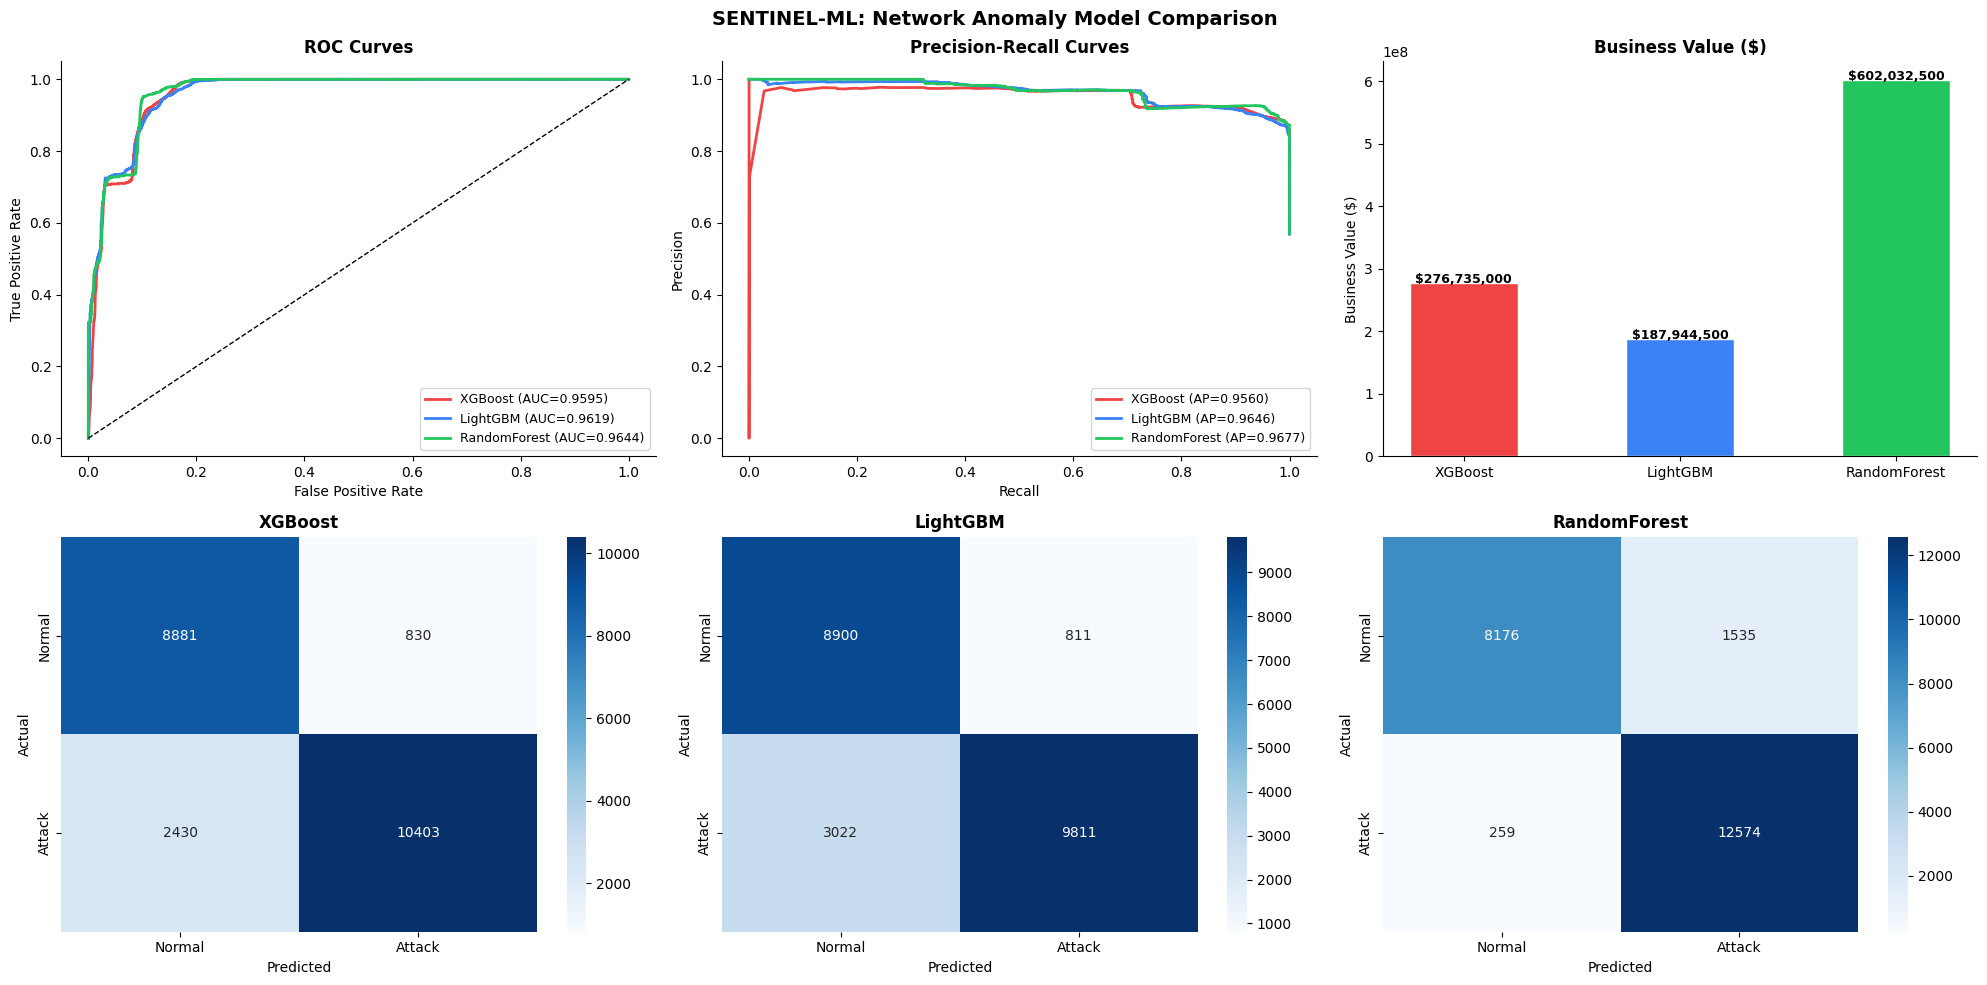

In [5]:
# Model Comparison Plots
print("MODEL COMPARISON")
print()

comparison = pd.DataFrame([{
    "Model": r["name"], "AUC-ROC": r["auc_roc"],
    "F1": r["f1"], "Recall": r["recall"], "Precision": r["precision"],
    "Caught Attacks": r["tp"], "Missed Attacks": r["fn"],
    "False Alarms": r["fp"], "Business Value $": r["business_value"]
} for r in results_list])
print(comparison.to_string(index=False))

from sklearn.metrics import roc_curve, precision_recall_curve
colors = {"XGBoost": "#ef4444", "LightGBM": "#3b82f6", "RandomForest": "#22c55e"}

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
for r in results_list:
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    ax1.plot(fpr, tpr, color=colors[r["name"]], linewidth=2,
             label=f"{r['name']} (AUC={r['auc_roc']:.4f})")
ax1.plot([0,1],[0,1],"k--", linewidth=1)
ax1.set_title("ROC Curves", fontweight="bold")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])
for r in results_list:
    p, rec, _ = precision_recall_curve(y_test, r["y_prob"])
    ax2.plot(rec, p, color=colors[r["name"]], linewidth=2,
             label=f"{r['name']} (AP={r['avg_precision']:.4f})")
ax2.set_title("Precision-Recall Curves", fontweight="bold")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(fontsize=9)

ax3 = fig.add_subplot(gs[0, 2])
bv = [r["business_value"] for r in results_list]
names = [r["name"] for r in results_list]
bars = ax3.bar(names, bv, color=[colors[n] for n in names], edgecolor="white", width=0.5)
ax3.set_title("Business Value ($)", fontweight="bold")
ax3.set_ylabel("Business Value ($)")
for bar, val in zip(bars, bv):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50000,
             f"${val:,}", ha="center", fontsize=9, fontweight="bold")

for i, r in enumerate(results_list):
    ax = fig.add_subplot(gs[1, i])
    cm = confusion_matrix(y_test, (r["y_prob"] >= r["threshold"]).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal","Attack"], yticklabels=["Normal","Attack"])
    ax.set_title(f"{r['name']}", fontweight="bold")
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")

plt.suptitle("SENTINEL-ML: Network Anomaly Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/network_anomaly/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
print("SHAP AND SAVE BEST MODEL")
print()

best = max(results_list, key=lambda x: x["auc_roc"])
best_model = {"XGBoost": xgb_model, "LightGBM": lgbm_model, "RandomForest": rf_model}[best["name"]]
print(f"Best: {best['name']} | AUC={best['auc_roc']} | F1={best['f1']} | Value=${best['business_value']:,}")

try:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_s.iloc[:200])
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
    else:
        shap_vals = shap_values
    if shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 1]
    feat_imp_shap = pd.Series(
        np.abs(shap_vals).mean(axis=0),
        index=feature_cols[:shap_vals.shape[1]]
    ).sort_values(ascending=False)
    print("Top 10 by SHAP:")
    for i, (f, v) in enumerate(feat_imp_shap.head(10).items(), 1):
        print(f"  {i:2}. {f:<35} {v:.6f}")
except Exception as e:
    print(f"SHAP skipped: {e}")
    feat_imp = pd.Series(
        best_model.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False)
    print("Top 10 by Feature Importance:")
    for i, (f, v) in enumerate(feat_imp.head(10).items(), 1):
        print(f"  {i:2}. {f:<35} {v:.6f}")

joblib.dump(best_model, "../../models/network_anomaly/best_model.pkl")

report = {
    "best_model": str(best["name"]),
    "auc_roc": float(best["auc_roc"]),
    "avg_precision": float(best["avg_precision"]),
    "f1": float(best["f1"]),
    "precision": float(best["precision"]),
    "recall": float(best["recall"]),
    "mcc": float(best["mcc"]),
    "optimal_threshold": float(best["threshold"]),
    "attacks_caught": int(best["tp"]),
    "attacks_missed": int(best["fn"]),
    "false_alarms": int(best["fp"]),
    "business_value": int(best["business_value"]),
    "n_test": int(len(y_test)),
    "n_test_attacks": int(y_test.sum()),
    "feature_count": int(len(feature_cols))
}

with open("../../models/network_anomaly/model_report.json", "w") as f:
    json.dump(report, f, indent=4)

print()
print(f"AUC-ROC        : {best['auc_roc']}")
print(f"F1 Score       : {best['f1']}")
print(f"Recall         : {best['recall']}")
print(f"Business Value : ${best['business_value']:,}")
print()
print("Notebook 3 complete.")

SHAP AND SAVE BEST MODEL

Best: RandomForest | AUC=0.964449 | F1=0.933413 | Value=$602,032,500
Top 10 by SHAP:
   1. network_risk_score                  0.080809
   2. bytes_log                           0.055034
   3. total_bytes                         0.050514
   4. service_attack_rate                 0.041849
   5. src_bytes                           0.036289
   6. src_bytes_log                       0.033495
   7. dst_bytes                           0.023179
   8. is_zero_dst                         0.020064
   9. dst_bytes_log                       0.016048
  10. dst_host_srv_count                  0.012972

AUC-ROC        : 0.964449
F1 Score       : 0.933413
Recall         : 0.979818
Business Value : $602,032,500

Notebook 3 complete.
